In [4]:
import numpy as np
import control as cnt
import matplotlib.pyplot as plt
import plotly.graph_objects as go

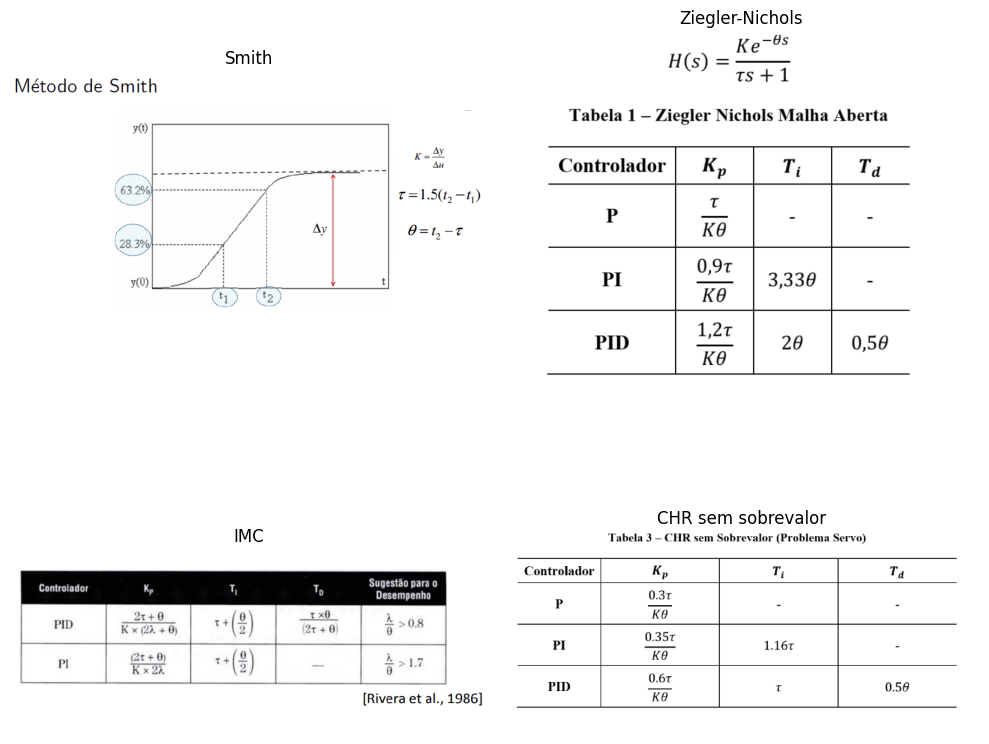

In [30]:
import matplotlib.image as mpimg

img1 = mpimg.imread('Smith.png')
img2 = mpimg.imread('ZN.png')
img3 = mpimg.imread('IMC.png')
img4 = mpimg.imread('CHR.png')

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0, 0].imshow(img1)
axs[0, 0].set_title('Smith')
axs[0, 0].axis('off')         

axs[0, 1].imshow(img2)
axs[0, 1].set_title('Ziegler-Nichols')
axs[0, 1].axis('off')

axs[1, 0].imshow(img3)
axs[1, 0].set_title('IMC')
axs[1, 0].axis('off')

axs[1, 1].imshow(img4)
axs[1, 1].set_title('CHR sem sobrevalor')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Exercício 1

In [27]:
# Pelo método Smith:
k = 60
tau = 40.5
theta = 1.5

# Ziegler-Nichols (PID - Malha aberta)
kp_zn = 0.54
ti_zn = 3
td_zn = 0.75

# IMC
# lambda > 1.2 => foi usado um lambda de 1.3
kp_imc = 0.335
ti_imc = 41.25
td_imc = 0.736

# CHR sem sobrevalor
kp_chr = 0.27
ti_chr = 40.5
td_chr = 0.75

In [36]:
def resposta_degrau(k, tau, theta, kp, ti, td):
    num = np. array ([k])
    den = np. array ([tau , 1])
    H = cnt.tf(num , den)
    n_pade = 10
    ( num_pade , den_pade ) = cnt.pade ( theta , n_pade )
    H_pade = cnt.tf( num_pade , den_pade )
    numkp = np. array ([kp])
    denkp = np. array ([1])
    numki = np. array ([kp])
    denki = np. array ([ti,0])
    numkd = np. array ([kp*td,0])
    denkd = np. array ([1])
    Hkp = cnt.tf(numkp , denkp)
    Hki=cnt.tf(numki , denki)
    Hkd=cnt.tf(numkd , denkd)
    Hctrl1 = cnt.parallel (Hkp , Hki)
    Hctrl = cnt.parallel (Hctrl1 , Hkd)
    Hs = cnt.series (H , H_pade)
    Hdel = cnt.series (Hs , Hctrl)
    Hcl = cnt.feedback(Hdel, 1)
    
    
    t = np . linspace (0 , 40 , 100)
    (t , y ) = cnt.step_response ( Hcl, t )
    return t, y
    plt.plot (t , y )
    plt.xlabel ( ' t [ s ] ')
    plt.ylabel('Amplitude')
    plt.title('Controle proporcional-integral-derivativo')
    
    plt.grid ()
    plt.show()

In [37]:
# Ziegler-Nichols
t_zn, y_zn = resposta_degrau(k, tau, theta, kp_zn, ti_zn, td_zn)

In [38]:
# IMC
t_imc, y_imc = resposta_degrau(k, tau, theta, kp_imc, ti_imc, td_imc)

In [40]:
# CHR sem sobrevalor
t_chr, y_chr = resposta_degrau(k, tau, theta, kp_chr, ti_chr, td_chr)

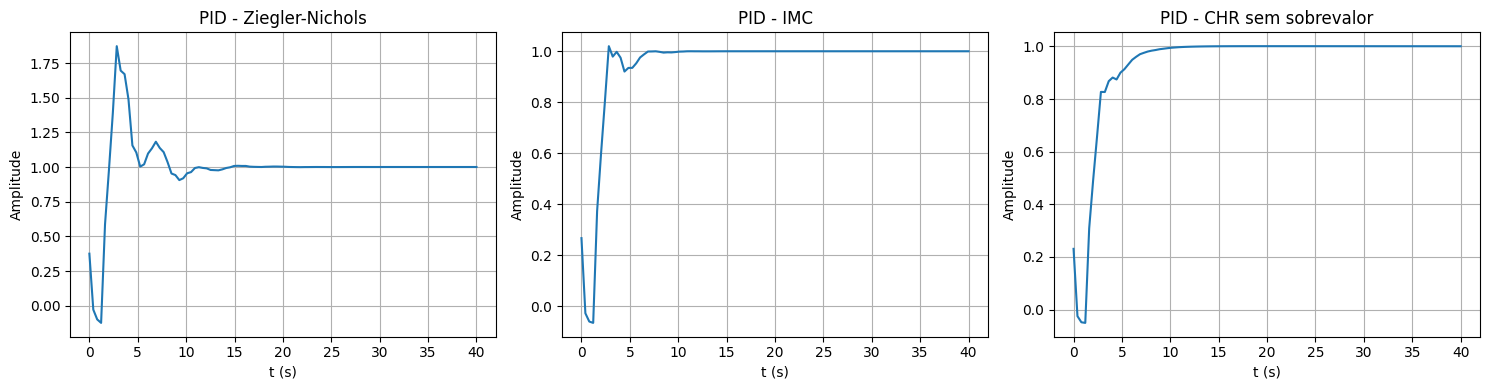

In [41]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(t_zn, y_zn)
axs[0].set_title('PID - Ziegler-Nichols')
axs[0].set_xlabel('t (s)')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True)

axs[1].plot(t_imc, y_imc)
axs[1].set_title('PID - IMC')
axs[1].set_xlabel('t (s)')
axs[1].set_ylabel('Amplitude')
axs[1].grid(True)

axs[2].plot(t_chr, y_chr)
axs[2].set_title('PID - CHR sem sobrevalor')
axs[2].set_xlabel('t (s)')
axs[2].set_ylabel('Amplitude')
axs[2].grid(True)

# Ajusta o espaçamento para os textos e eixos não se sobreporem
plt.tight_layout()
plt.show()

### Comparação dos 3 métodos

- O método ZN produz uma resposta com mais de 75% de sobressinal; Esse é o método cuja resposta apresenta mais oscilações e mais demora a estabilizar, por volta de 15s;
- IMC apresenta apenas um pequeno sobressinal e pequenas oscilações antes de estabilizar por volta de 10s;
- CHR não apresenta oscilações relevantes e também estabiliza por volta dos 10s;
- Como os 3 métodos utilizam a mesma planta, o tempo de atraso é o mesmo para os 3.

# Exercício 2

Os métodos de Ziegler-Nichols e CHR são usados como ponto de partida porque se baseiam em modelos matemáticos simplificados e aproximados de processos reais. Eles servem para encontrar rapidamente parâmetros iniciais estáveis, mas não costumam ser usados como ajuste final devido à limitações de desempenho e segurança.

# Exercício 3

### a) Irrigação automatizada - $G(s) = \frac{2.5*e^{-4s}}{20s + 1}$
$K_p$ = 2,4   |   $T_i$ = 8s   |   $T_d$ = 2s

### b) Esteira transportadora industrial - $G(s) = \frac{1.8*e^{-0.8s}}{3s + 1}$
$K_p$ = 2,5   |   $T_i$ = 1,6s   |   $T_d$ = 0,4s

O sistema b seria mais sensível ao atraso de 300ms, porque seu tempo morto original é de 0.8s. Isso significa que o atraso adicional de comunicação WI-FI representa 37.5% do valor de $\theta$. Além disso, o sistema b apresenta um menor valor de $T_i$, tornando o atraso adicional mais significativo em relação à dinâmica do controlador.

# Exercício 4

$$G(s) = \frac{1.5*e^{-1s}}{6s + 1}$$

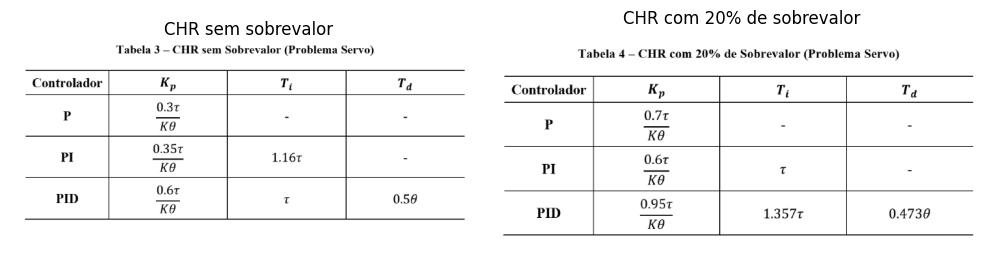

In [42]:
import matplotlib.image as mpimg

img1 = mpimg.imread('CHR.png')
img2 = mpimg.imread('CHR_CS.png')

fig, axs = plt.subplots(1, 2, figsize=(10, 10))

axs[0].imshow(img1)
axs[0].set_title('CHR sem sobrevalor')
axs[0].axis('off')         

axs[1].imshow(img2)
axs[1].set_title('CHR com 20% de sobrevalor')
axs[1].axis('off')

plt.tight_layout()
plt.show()

In [43]:
k = 1.5
tau = 6
theta = 1

# CHR sem sobrevalor
kp_ss = 2.4
ti_ss = 6
td_ss = 0.5

# CHR com 20% de sobrevalor
kp_cs = 3.8
ti_cs = 8.142
td_cs = 0.473

# Respostas ao degrau de valor 15
t_ss, y_ss = resposta_degrau(k, tau, theta, kp_ss, ti_ss, td_ss)
y_ss = 15*y_ss

t_cs, y_cs = resposta_degrau(k, tau, theta, kp_cs, ti_cs, td_cs)
y_cs = 15*y_cs

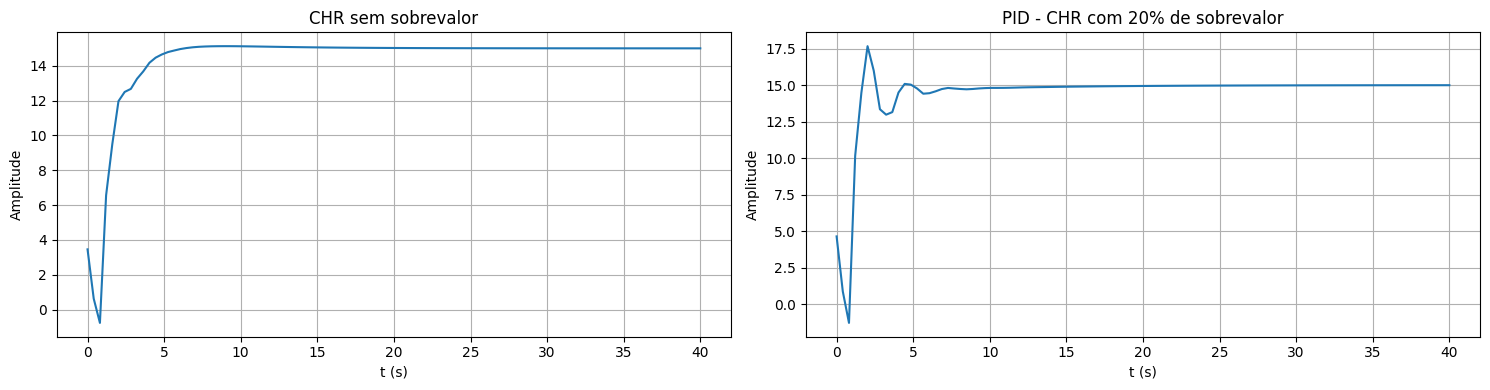

In [44]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4))

axs[0].plot(t_ss, y_ss)
axs[0].set_title('CHR sem sobrevalor')
axs[0].set_xlabel('t (s)')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True)

axs[1].plot(t_cs, y_cs)
axs[1].set_title('PID - CHR com 20% de sobrevalor')
axs[1].set_xlabel('t (s)')
axs[1].set_ylabel('Amplitude')
axs[1].grid(True)

# Ajusta o espaçamento para os textos e eixos não se sobreporem
plt.tight_layout()
plt.show()

### Comparação dos ajustes

Eu recomendaria o ajuste CHR sem sobrevalor, pois ele possui um $K_p$ menor, de 2,4, e sua resposta não apresenta sobressinal relevante. Como se trata de um data center, em que se a temperatura ultrapassar a temperatura-alvo, há o risco de acelerar o desgaste dos equipamentos, o sistema ideal seria o que reduz esse risco, portanto, o sistema sem sobrevalor.

# Exercício 5

Para $\lambda$ = 1.5$\theta$  ->   $K_p$ = 0.229

Para $\lambda$ = 4$\theta$    ->   $K_p$ = 0.105

Em ambos os casos, $T_d$ = 0.736s e $T_i$ = 41.25s

In [46]:
k = 60
tau = 40.5
theta = 1.5
kp1 = 0.229
kp2 = 0.105
ti = 41.25
td = 0.736

# Respostas ao degrau de valor 20
t1, y1 = resposta_degrau(k, tau, theta, kp1, ti, td)
y1 = 20*y1

t2, y2 = resposta_degrau(k, tau, theta, kp2, ti, td)
y2 = 20*y2

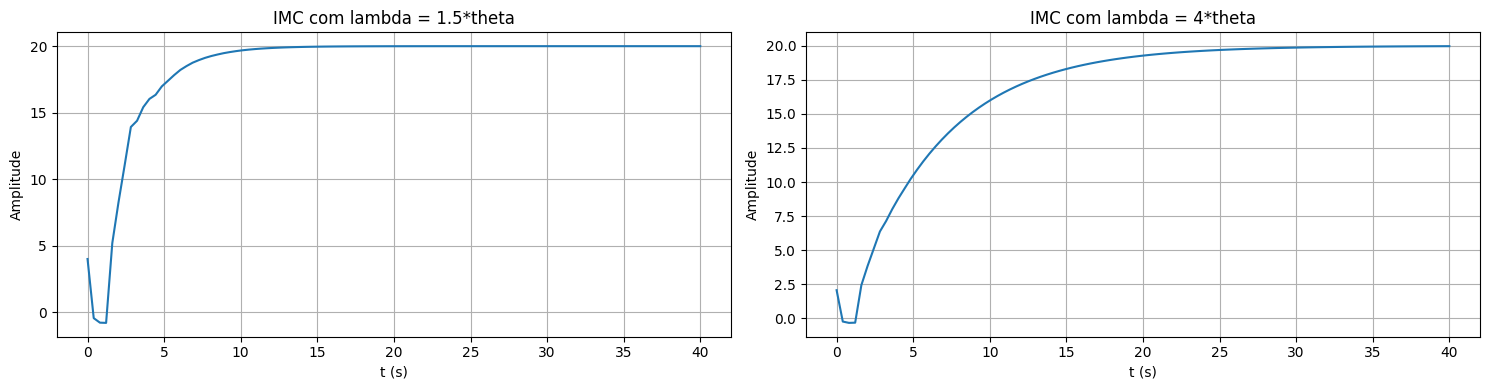

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4))

axs[0].plot(t1, y1)
axs[0].set_title('IMC com lambda = 1.5*theta')
axs[0].set_xlabel('t (s)')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True)

axs[1].plot(t2, y2)
axs[1].set_title('IMC com lambda = 4*theta')
axs[1].set_xlabel('t (s)')
axs[1].set_ylabel('Amplitude')
axs[1].grid(True)

# Ajusta o espaçamento para os textos e eixos não se sobreporem
plt.tight_layout()
plt.show()

Quanto maior o valor de $\lambda$, mais lenta é a resposta do sistema, enquanto valores menores produzem uma resposta mais rápida. Para esse caso, como a estufa está sujeita a perturbações frequentes causadas pelas rajadas de vento, eu escolheria $\lambda$ = 2,25s. Embora valores maiores de $\lambda$ proporcionem maior robustez, neste caso é importante que o controlador responda rapidamente às alterações de temperatura provocadas pela abertura e fechamento das telas de ventilação.